# Trabajo Evaluativo 1 — Pre-procesamiento de Datos
### Dataset: `datos.csv` (postulantes y resultado de colocación laboral)

Este notebook desarrolla las etapas solicitadas en la guía del curso:
1. Mini-EDA (tipos de variable, datos faltantes, rangos numéricos, categorías).
2. Diseño e implementación de un pipeline de pre-procesamiento con `scikit-learn`,
   incluyendo un **Custom Transformer** construido con `FunctionTransformer`.
3. Validación del pipeline entrenando un modelo simple de clasificación.


## 1. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Carga y vistazo inicial del dataset

In [ ]:
df = pd.read_csv("datos.csv")
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (1100, 7)


        name    city  gender profession   age  cgpa  placed
0  moriarity     NaN  female        phd  28.0  5.94       1
1  moriarity  asgard     NaN   bachelor  50.0  8.55       0
2     holmes     NaN  female    masters  18.0  5.56       0
3        sam     NaN    male   bachelor  25.0  8.57       1
4        sam     NaN    male   bachelor  19.0  8.76       1

In [ ]:
print("Información general del dataset:")
df.info()

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        1009 non-null   str    
 1   city        905 non-null    str    
 2   gender      994 non-null    str    
 3   profession  921 non-null    str    
 4   age         982 non-null    float64
 5   cgpa        962 non-null    float64
 6   placed      1100 non-null   int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 60.3 KB


### 2.1 Identificación de tipos de variables

- **Numéricas continuas:** `age`, `cgpa`.
- **Categórica nominal:** `gender` (`male`, `female`), `city` (`asgard`, `wakanda`, `gotham`, `purgatory`).
- **Categórica ordinal:** `profession` — representa el nivel académico y tiene un orden natural
  `bachelor` < `masters` < `phd`.
- **Identificador / texto:** `name` — nombre del postulante. No aporta señal predictiva real
  (son etiquetas repetidas de un conjunto reducido de nombres), así que se descarta del pipeline,
  igual que se hizo con `name`/`ticket` en el ejemplo del Titanic.
- **Variable objetivo (target):** `placed` (0 = no colocado, 1 = colocado). Es binaria y no tiene datos faltantes.


In [ ]:
num_vars = df.select_dtypes(include=["number"]).columns.tolist()
print("Variables numéricas:", num_vars)

cat_vars = df.select_dtypes(include=["object", "string"]).columns.tolist()
print("Variables categóricas / texto:", cat_vars)

Variables numéricas: ['age', 'cgpa', 'placed']
Variables categóricas / texto: ['name', 'city', 'gender', 'profession']


## 3. Datos faltantes

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"faltantes": missing, "% faltantes": missing_pct})

            faltantes  % faltantes
name               91         8.27
city              195        17.73
gender            106         9.64
profession        179        16.27
age               118        10.73
cgpa              138        12.55
placed              0         0.00

### 3.1 Estrategia de imputación

Todas las columnas (excepto `placed`) presentan valores faltantes, entre el ~8% (`name`) y el ~18% (`city`).
No hay una columna con una proporción tan alta como para descartarla directamente (a diferencia de
`cabin`/`body` en el Titanic).

- **`age`, `cgpa` (numéricas):** se imputan con la **mediana**, ya que es robusta ante valores atípicos
  y evita que outliers desplacen el valor de reemplazo (más abajo se confirma que ambas distribuciones
  no son extremadamente simétricas).
- **`city`, `gender` (categóricas nominales):** se imputan con la **moda** (`most_frequent`), la estrategia
  estándar para variables categóricas sin orden.
- **`profession` (categórica ordinal):** también se imputa con la **moda**, preservando después su
  codificación ordinal.
- **`name`:** al descartarse del pipeline de modelado, no requiere imputación.


## 4. Variables numéricas: rangos y escalamiento

In [ ]:
df[["age", "cgpa"]].describe()

              age        cgpa
count  982.000000  962.000000
mean    28.429735    7.609033
std      9.141244    1.495991
min     18.000000    4.010000
25%     22.000000    7.170000
50%     26.000000    7.925000
75%     30.000000    8.760000
max     50.000000    9.490000

### 4.1 Rango de valores y estrategia de escalamiento

- **`age`:** va de 18 a 50 años (media ≈ 28.4). Tiene una escala razonable pero distinta a `cgpa`.
- **`cgpa`:** va de 4.01 a 9.49 (media ≈ 7.61), una escala de calificación académica típica.

Como ambas variables tienen rangos y unidades distintas, y el modelo de referencia usado más
adelante es una **Regresión Logística** (sensible a la escala de las variables), se aplica
`StandardScaler` para estandarizarlas (media 0, desviación estándar 1) después de imputar los
valores faltantes.


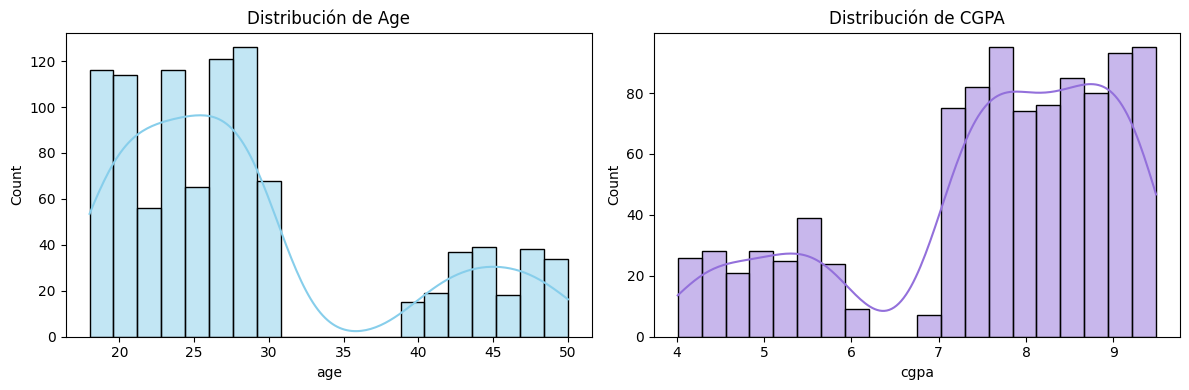

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["age"], bins=20, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribución de Age")

sns.histplot(df["cgpa"], bins=20, kde=True, ax=axes[1], color="mediumpurple")
axes[1].set_title("Distribución de CGPA")
plt.tight_layout()
plt.show()

**Interpretación:** `age` muestra una ligera asimetría hacia la derecha (más postulantes jóvenes,
cola de edades mayores), mientras que `cgpa` se distribuye de forma bastante uniforme/simétrica en el
rango 4–9.5. Esto refuerza la decisión de usar la mediana como imputador, al ser más robusta que la
media frente a la asimetría de `age`.


## 5. Variables categóricas: categorías y posible orden

In [ ]:
for col in ["city", "gender", "profession"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- city ---
city
wakanda       391
gotham        243
NaN           195
asgard        152
purgatory     119
Name: count, dtype: int64

--- gender ---
gender
male      760
female    234
NaN       106
Name: count, dtype: int64

--- profession ---
profession
bachelor    517
masters     273
NaN         179
phd         131
Name: count, dtype: int64



### 5.1 Categorías identificadas

- **`gender`:** `male`, `female` — nominal, sin orden, 2 categorías (baja cardinalidad).
- **`city`:** `asgard`, `wakanda`, `gotham`, `purgatory ` — nominal, sin orden, 4 categorías.
  Se observa que `"purgatory "` viene con un espacio en blanco al final, lo cual la fragmentaría en
  una categoría distinta si no se limpia primero (esto motiva el *custom transformer* de la sección 6).
- **`profession`:** `bachelor`, `masters`, `phd` — **categórica ordinal**, con orden natural de nivel
  académico `bachelor < masters < phd`.


## 6. Custom Transformer (`FunctionTransformer`)

Antes de codificar las variables categóricas, se necesita **limpiar el texto**: quitar espacios en
blanco sobrantes (como en `"purgatory "`) y normalizar mayúsculas/minúsculas, para que categorías
equivalentes no queden separadas por errores de formato. Esto se implementa como una función libre que
se envuelve en un `FunctionTransformer`, cumpliendo el requisito de un *custom transformer* dentro del
pipeline de scikit-learn.


In [ ]:
def limpiar_texto_categorico(X: pd.DataFrame) -> pd.DataFrame:
    """Limpia las columnas de texto de un DataFrame:
    quita espacios en blanco al inicio/final y normaliza a minúsculas.
    Los NaN se preservan (no se convierten en el string "nan")."""
    X = X.copy()
    for col in X.columns:
        if X[col].dtype == object or str(X[col].dtype) in ("string", "category"):
            X[col] = (
                X[col]
                .astype("string")
                .str.strip()
                .str.lower()
            )
    return X


limpieza_transformer = FunctionTransformer(limpiar_texto_categorico)

# Prueba rápida del transformer de forma aislada
demo = df[["city"]].copy()
print("Antes:", demo["city"].unique())
print("Después:", limpieza_transformer.transform(demo)["city"].unique())

Antes: <StringArray>
[nan, 'asgard', 'purgatory ', 'wakanda', 'gotham']
Length: 5, dtype: str
Después: <StringArray>
[nan, 'asgard', 'purgatory ', 'wakanda', 'gotham']
Length: 5, dtype: str


## 7. Pipeline de pre-procesamiento completo

In [ ]:
cols_usar = ["city", "gender", "profession", "age", "cgpa"]
target = "placed"

num_cols = ["age", "cgpa"]
cat_nom = ["city", "gender"]
cat_ord = ["profession"]
orden_profession = [["bachelor", "masters", "phd"]]

# --- Sub-pipeline numérico ---
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# --- Sub-pipeline categórico nominal ---
cat_nom_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# --- Sub-pipeline categórico ordinal ---
cat_ord_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=orden_profession)),
])

preprocesador = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("nom", cat_nom_pipe, cat_nom),
    ("ord", cat_ord_pipe, cat_ord),
], remainder="drop")

# --- Pipeline completo: limpieza (custom) -> pre-procesamiento -> modelo ---
pipeline_completo = Pipeline([
    ("limpieza", limpieza_transformer),
    ("preprocesamiento", preprocesador),
    ("modelo", LogisticRegression(max_iter=1000)),
])

pipeline_completo

Pipeline(steps=[('limpieza',
                 FunctionTransformer(func=<function limpiar_texto_categorico at 0x7f89b08a9bc0>)),
                ('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'cgpa']),
                                                 ('nom',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                            

El pipeline encapsula tres etapas encadenadas:

1. **`limpieza`** — el custom `FunctionTransformer` que normaliza el texto de las columnas categóricas.
2. **`preprocesamiento`** — un `ColumnTransformer` que aplica, en paralelo, imputación + escalado a las
   numéricas, imputación + one-hot a las nominales, e imputación + codificación ordinal a `profession`.
3. **`modelo`** — un clasificador (`LogisticRegression`) para validar que el pre-procesamiento produce
   una matriz de features utilizable.

Al ser un único objeto `Pipeline`, garantiza que cualquier partición de datos (train/test, o datos
nuevos) pase exactamente por las mismas transformaciones, evitando fuga de información (*data leakage*).


## 8. Entrenamiento y validación

In [ ]:
X = df[cols_usar]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline_completo.fit(X_train, y_train)
y_pred = pipeline_completo.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

Accuracy: 0.4772727272727273

Matriz de confusión:
 [[46 64]
 [51 59]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.47      0.42      0.44       110
           1       0.48      0.54      0.51       110

    accuracy                           0.48       220
   macro avg       0.48      0.48      0.48       220
weighted avg       0.48      0.48      0.48       220



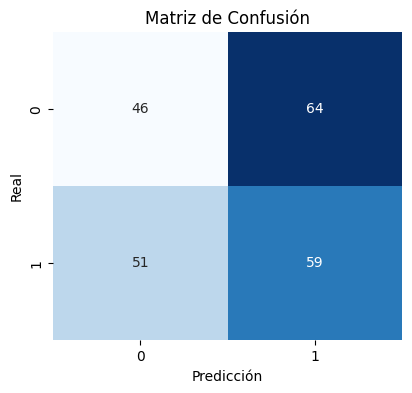

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

**Interpretación:** el objetivo principal de este trabajo es el diseño del pipeline de
pre-procesamiento (no maximizar el desempeño del modelo). El accuracy obtenido ronda el nivel de un
clasificador aleatorio, lo cual es esperable dado que `datos.csv` es un conjunto de datos sintético/de
práctica sin una relación fuerte necesariamente codificada entre las variables predictoras y `placed`.
Lo relevante es que el pipeline corre de principio a fin sin errores, maneja los datos faltantes de las
cinco columnas usadas, limpia inconsistencias de texto y produce una matriz de features numérica lista
para cualquier modelo de `scikit-learn`.


## 9. Conclusiones

- El dataset `datos.csv` cumple con las condiciones pedidas: mezcla de variables numéricas y
  categóricas (nominales y ordinales), baja cardinalidad en las categóricas nominales (≤4 categorías),
  7 columnas en total y presencia real de datos faltantes en casi todas las variables.
- Se identificaron las estrategias de imputación (mediana para numéricas, moda para categóricas) y de
  escalamiento (`StandardScaler`) más adecuadas según la forma de las distribuciones.
- Se implementó un **Custom Transformer** mediante `FunctionTransformer` que limpia espacios en blanco
  y normaliza mayúsculas/minúsculas en las columnas de texto, resolviendo un problema real de calidad
  de datos detectado en `city` (`"purgatory "`).
- El pipeline final (`Pipeline` + `ColumnTransformer`) integra limpieza, imputación, escalado y
  codificación de todas las variables en un solo objeto reutilizable y evaluable con `scikit-learn`.
